# Phase 2 · 4단원 — 결정 트리와 랜덤 포레스트

> **스무고개처럼 예/아니오 질문을 이어가며 답을 찾는 방법입니다. 그리고 나무 여러 그루를 심으면 훨씬 강해집니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/04-decision-trees>
- 예상 시간: 90분 · 선수 지식: 1~3단원

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **불순도**(지니·엔트로피)를 계산해서 "어디를 잘라야 좋은지" 정합니다.
2. 결정 트리를 **밑바닥부터** 만듭니다.
3. **랜덤 포레스트**로 나무 여러 그루를 심어 성능을 올립니다.
4. **특징 중요도**를 뽑아 "어떤 정보가 중요했는지" 설명합니다.

### 🔑 3단원까지와 완전히 다른 방식입니다

| | 2·3단원 (선형·로지스틱) | 4단원 (결정 트리) |
| --- | --- | --- |
| 방식 | 숫자를 곱하고 더함 | **예/아니오 질문을 이어감** |
| 경계 모양 | **직선만** | **계단 모양 (곡선 흉내 가능)** |
| 학습 방법 | 경사하강법 | **좋은 질문 찾기 (반복 없음)** |
| 사람이 이해 | 어려움 | **쉬움 (규칙을 읽을 수 있음)** |

> **3단원까지 못 나누던 도넛 모양 데이터를 드디어 다룰 수 있게 됩니다.**

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 스무고개 — 결정 트리가 하는 일 | 📗 원문 |
| 1 | 🔑 불순도 — "얼마나 섞여 있나" 재기 | 📗 원문 + ✨ 손 계산 |
| 2 | 정보 이득 — 어디를 잘라야 좋은가 | 📗 원문 + ✨ 손 계산 |
| 3 | 🔨 가장 좋은 자를 곳 찾기 | 📗 원문 |
| 4 | 🔨 결정 트리 만들기 | 📗 원문 |
| 5 | 멈추는 조건 — 안 그러면 다 외웁니다 | 📗 원문 + ✨ 실험 |
| 6 | 숫자를 예측하는 트리 | 📗 원문 |
| 7 | 🔑 랜덤 포레스트 — 나무 여러 그루 심기 | 📗 원문 + ✨ 비유 |
| 8 | 특징 중요도 | 📗 원문 |
| 9 | 트리가 신경망을 이기는 경우 | 📗 원문 |
| 10 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 "예/아니오 질문을 이어가면 된다"는 아이디어를 봅니다. 스무고개죠.
그런데 스무고개를 잘하려면 **좋은 질문을 골라야** 합니다. **"좋은 질문"이 뭘까요?**

이 한 질문이 1~4절을 끌고 갑니다.

- **1절 🔑 불순도** — 좋은 질문이란 **답이 잘 갈리는 질문**입니다. 그럼 "잘 갈렸다"를 재는 **자**가 필요합니다.
  그 자가 **지니**와 **엔트로피**입니다.
- **2절 정보 이득** — 1절의 자로 **자르기 전과 후를 비교**합니다. 많이 줄어들수록 좋은 질문이죠.
- **3절 🔨** — 이제 **모든 특징 × 모든 기준값**을 훑어서 정보 이득이 가장 큰 질문을 찾습니다.
- **4절 🔨** — 3절을 **재귀로 반복**하면 트리가 됩니다. 자르고, 또 자르고, 또 자르고.

그런데 계속 자르면 어떻게 될까요?

- **5절 멈추는 조건** — **끝까지 자르면 점 하나하나를 다 외웁니다.** 1단원의 과적합이 여기서도 나옵니다.
  깊이 제한이 필요합니다.
- **6절 회귀 트리** — 여기까지 분류였습니다. **불순도만 분산으로 바꾸면** 숫자 예측도 됩니다.

이제 트리 한 그루의 근본적인 약점을 마주합니다.

- **7절 🔑 랜덤 포레스트** — 나무 한 그루는 **데이터가 조금만 바뀌어도 모양이 확 달라집니다.**
  불안정하다는 뜻이죠. 그럼 **여러 그루를 심어서 다수결**을 하면 어떨까요?
- **8절 특징 중요도** — 숲을 만들고 나면 규칙을 읽을 수 없게 됩니다(나무가 수십 그루니까요).
  대신 **"어떤 정보가 중요했나"**를 뽑아낼 수 있습니다.
- **9절** — 마지막으로, 왜 표 형태 데이터에서는 **트리가 아직도 신경망을 이기는지** 봅니다.

### 한 줄로 꿰면

> **질문을 이어가자(0) → 좋은 질문을 재는 자를 만들고(1) → 그 자로 비교하고(2)
> → 최고의 질문을 찾고(3) → 재귀로 트리를 키우고(4) → 너무 키우지 않게 막고(5)
> → 회귀로 넓히고(6) → 한 그루의 불안정을 숲으로 해결하고(7) → 중요도를 읽고(8) → 실무 위치 확인(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
from collections import Counter

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 스무고개 — 결정 트리가 하는 일

> 📗 **원문** — "What a decision tree does"

결정 트리는 **예/아니오 질문을 이어가며** 답을 찾습니다. 스무고개랑 똑같아요.

```
                   [나이 < 30살?]
                   /            \
                예                아니오
                /                    \
      [소득 > 5천만?]            [신용점수 > 700?]
        /        \                 /         \
      예         아니오           예          아니오
      /            \             /              \
   승인          거절         승인            거절
```

### 🧸 읽는 법

1. **맨 위(뿌리)에서 시작**합니다
2. 질문에 답하며 **가지를 타고 내려갑니다**
3. **맨 아래(잎)에 도착**하면 그게 답입니다

### 🔑 3단원까지와의 결정적 차이

로지스틱 회귀는 이렇게 답했습니다.

> `0.7 × 나이 + 1.2 × 소득 − 3.5 > 0` 이면 승인

**사람이 이걸 보고 이해할 수 있나요?** 어렵습니다.

결정 트리는 이렇게 답합니다.

> "30살 미만이고 소득이 5천만 넘으면 승인"

**그냥 읽으면 됩니다.** 이게 트리의 가장 큰 장점입니다.
은행 대출이나 의료 진단처럼 **"왜 그렇게 판단했는지 설명해야 하는"** 곳에서 특히 중요해요.

### 📐 어떻게 만드나

**위에서 아래로** 만듭니다. 각 단계에서 이렇게 물어요.

> **"어떤 질문을 하면 데이터가 가장 깔끔하게 갈라질까?"**

'깔끔하게'가 뭔지 재는 방법이 필요합니다. 그게 1절의 **불순도**입니다.

## 1️⃣ 🔑 불순도 — "얼마나 섞여 있나" 재기

> 🔗 **앞 절과 이어서** — 0절에서 "예/아니오 질문을 이어가면 된다"는 걸 봤습니다.
> 그런데 **어떤 질문을 먼저 던져야 좋을까요?** 스무고개도 첫 질문이 중요하잖아요.
> 좋은 질문을 고르려면, 먼저 **"잘 갈렸다"를 재는 자**가 있어야 합니다.

> 📗 **원문** — "Split criteria: measuring impurity"

### 🧸 비유 — 사탕 봉지

봉지 안에 사탕이 들어 있습니다.

- **빨간 사탕만 10개** → 깔끔합니다. 손 넣으면 무조건 빨강 ✅
- **빨강 5개, 파랑 5개** → 엉망입니다. 뭐가 나올지 몰라요 ❌

**불순도**는 이 "엉망인 정도"를 숫자로 잰 것입니다.

### 📐 방법 ① 지니 불순도 (Gini impurity)

$$\text{Gini} = 1 - \sum p_k^2$$

`pₖ`는 각 종류의 비율입니다.

**말로 풀면:** "눈 감고 하나 뽑아서 아무 이름표나 붙였을 때 **틀릴 확률**"

```
예: 고양이 6마리, 강아지 4마리

고양이 비율 0.6, 강아지 비율 0.4
Gini = 1 - (0.6² + 0.4²)
     = 1 - (0.36 + 0.16)
     = 0.48
```

### 📐 방법 ② 엔트로피 (Entropy)

$$\text{Entropy} = -\sum p_k \log_2 p_k$$

**말로 풀면:** "결과를 알아내려면 예/아니오 질문을 몇 번 해야 하나"

```
같은 예: 고양이 6, 강아지 4

Entropy = -(0.6 × log₂0.6 + 0.4 × log₂0.4)
        = 0.971 비트
```

### 🔑 두 값의 성질 (똑같습니다)

| 상태 | 지니 | 엔트로피 | 뜻 |
| --- | --- | --- | --- |
| **한 종류만** | 0 | 0 | 완벽하게 깔끔 ✅ |
| 반반 (2종류) | 0.5 | 1.0 | 가장 엉망 ❌ |

**둘 다 낮을수록 좋습니다.** 실무에서는 지니를 더 많이 씁니다 (`log` 계산이 없어서 빠름).

> ✨ **추가** — 사탕 봉지 여러 개로 손 계산을 해 봅시다.

In [2]:
def 지니(라벨들):
    if len(라벨들) == 0:
        return 0.0
    개수 = Counter(라벨들)
    총합 = len(라벨들)
    return 1 - sum((c / 총합) ** 2 for c in 개수.values())

def 엔트로피(라벨들):
    if len(라벨들) == 0:
        return 0.0
    개수 = Counter(라벨들)
    총합 = len(라벨들)
    return -sum((c/총합) * math.log2(c/총합) for c in 개수.values() if c > 0)

봉지들 = [
    ("빨강 10개만",              ["빨강"] * 10),
    ("빨강 9, 파랑 1",           ["빨강"] * 9 + ["파랑"]),
    ("빨강 6, 파랑 4",           ["빨강"] * 6 + ["파랑"] * 4),
    ("빨강 5, 파랑 5 (반반)",     ["빨강"] * 5 + ["파랑"] * 5),
    ("빨강 4, 파랑 3, 노랑 3",   ["빨강"]*4 + ["파랑"]*3 + ["노랑"]*3),
]

print("사탕 봉지의 '엉망인 정도' 재기\n")
print(f"{'봉지 내용':<26}{'지니':>10}{'엔트로피':>12}{'상태':>16}")
print("-" * 66)
for 이름, 사탕 in 봉지들:
    g, e = 지니(사탕), 엔트로피(사탕)
    상태 = "완벽 ✅" if g == 0 else ("깔끔" if g < 0.3 else "섞임" if g < 0.5 else "엉망 ❌")
    print(f"{이름:<26}{g:>10.4f}{e:>12.4f}{상태:>16}")

print("\n=> 한 종류만 있으면 둘 다 정확히 0입니다.")
print("   반반일 때 가장 큽니다 (지니 0.5, 엔트로피 1.0).")
print("\n💡 트리가 하는 일: '이 값을 최대한 낮추는 질문'을 찾는 것입니다.")

print("\n【 손 계산 확인 — 고양이 6, 강아지 4 】")
print(f"  지니 = 1 - (0.6² + 0.4²) = 1 - (0.36 + 0.16) = {1-(0.36+0.16):.2f}")
print(f"  코드 결과: {지니(['고양이']*6 + ['강아지']*4):.2f}  ✓")
print(f"\n  엔트로피 = -(0.6×log₂0.6 + 0.4×log₂0.4)")
print(f"           = -(0.6×{math.log2(0.6):.3f} + 0.4×{math.log2(0.4):.3f})")
print(f"           = {-(0.6*math.log2(0.6) + 0.4*math.log2(0.4)):.3f}")
print(f"  코드 결과: {엔트로피(['고양이']*6 + ['강아지']*4):.3f}  ✓")

사탕 봉지의 '엉망인 정도' 재기

봉지 내용                             지니        엔트로피              상태
------------------------------------------------------------------
빨강 10개만                       0.0000     -0.0000            완벽 ✅
빨강 9, 파랑 1                    0.1800      0.4690              깔끔
빨강 6, 파랑 4                    0.4800      0.9710              섞임
빨강 5, 파랑 5 (반반)               0.5000      1.0000            엉망 ❌
빨강 4, 파랑 3, 노랑 3              0.6600      1.5710            엉망 ❌

=> 한 종류만 있으면 둘 다 정확히 0입니다.
   반반일 때 가장 큽니다 (지니 0.5, 엔트로피 1.0).

💡 트리가 하는 일: '이 값을 최대한 낮추는 질문'을 찾는 것입니다.

【 손 계산 확인 — 고양이 6, 강아지 4 】
  지니 = 1 - (0.6² + 0.4²) = 1 - (0.36 + 0.16) = 0.48
  코드 결과: 0.48  ✓

  엔트로피 = -(0.6×log₂0.6 + 0.4×log₂0.4)
           = -(0.6×-0.737 + 0.4×-1.322)
           = 0.971
  코드 결과: 0.971  ✓


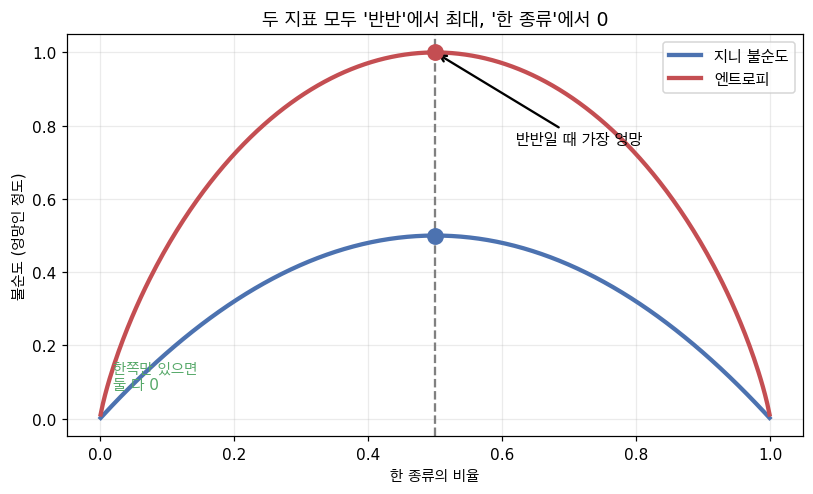

두 곡선의 '모양'이 거의 같습니다. 높이만 다를 뿐이에요.
그래서 어느 걸 써도 트리 결과는 거의 비슷하게 나옵니다.


In [3]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
비율 = np.linspace(0.001, 0.999, 300)
지니값 = 1 - (비율**2 + (1-비율)**2)
엔트값 = -(비율*np.log2(비율) + (1-비율)*np.log2(1-비율))

ax.plot(비율, 지니값, lw=2.8, color="#4c72b0", label="지니 불순도")
ax.plot(비율, 엔트값, lw=2.8, color="#c44e52", label="엔트로피")
ax.axvline(0.5, color="gray", ls="--", lw=1.5)
ax.plot(0.5, 0.5, "o", ms=10, color="#4c72b0", zorder=5)
ax.plot(0.5, 1.0, "o", ms=10, color="#c44e52", zorder=5)
ax.annotate("반반일 때 가장 엉망", (0.5, 1.0), xytext=(0.62, 0.75),
            fontsize=10.5, arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.02, 0.08, "한쪽만 있으면\n둘 다 0", fontsize=10, color="#55a868")
ax.set_xlabel("한 종류의 비율"); ax.set_ylabel("불순도 (엉망인 정도)")
ax.set_title("두 지표 모두 '반반'에서 최대, '한 종류'에서 0", fontsize=12.5)
ax.legend(fontsize=10.5); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("두 곡선의 '모양'이 거의 같습니다. 높이만 다를 뿐이에요.")
print("그래서 어느 걸 써도 트리 결과는 거의 비슷하게 나옵니다.")

## 2️⃣ 정보 이득 — 어디를 잘라야 좋은가

> 🔗 **앞 절과 이어서** — 1절에서 자를 만들었습니다. 이제 **자르기 전과 후를 비교**하면 됩니다.
> **"이 질문을 던졌더니 불순도가 얼마나 줄었나?"** 많이 줄면 좋은 질문입니다.

> 📗 **원문** — "Information gain"

이제 **"자르기 전"과 "자른 후"의 불순도를 비교**합니다.

$$\text{정보 이득} = (\text{자르기 전 불순도}) - (\text{자른 후 평균 불순도})$$

### 🧸 말로 풀면

> **"이 질문을 하면 얼마나 깔끔해지나?"**

- 정보 이득이 **크다** → 좋은 질문 ✅
- 정보 이득이 **0** → 해도 아무 소용 없는 질문 ❌

### ⚠️ '평균'을 낼 때 주의점

그냥 평균이 아니라 **가중 평균**입니다. **사람 수가 많은 쪽에 더 무게**를 줍니다.

```
왼쪽에 90명, 오른쪽에 10명이 갔다면
평균 불순도 = 0.9 × (왼쪽 불순도) + 0.1 × (오른쪽 불순도)
```

10명짜리 그룹이 아무리 깔끔해도, 90명이 엉망이면 전체는 엉망이니까요.

> ✨ **추가** — 좋은 질문과 나쁜 질문을 직접 비교해 봅시다.

In [4]:
def 정보이득(부모라벨, 왼쪽라벨, 오른쪽라벨, 불순도함수=지니):
    n = len(부모라벨)
    if n == 0:
        return 0.0
    왼비율 = len(왼쪽라벨) / n
    오른비율 = len(오른쪽라벨) / n
    자른후 = 왼비율 * 불순도함수(왼쪽라벨) + 오른비율 * 불순도함수(오른쪽라벨)
    return 불순도함수(부모라벨) - 자른후

# 고양이 5마리, 강아지 5마리 (완전히 섞인 상태)
부모 = ["고양이"] * 5 + ["강아지"] * 5
print(f"자르기 전: 고양이 5, 강아지 5   지니 = {지니(부모):.4f} (가장 엉망)\n")

질문들 = [
    ("완벽한 질문", ["고양이"]*5, ["강아지"]*5),
    ("괜찮은 질문", ["고양이"]*4 + ["강아지"]*1, ["고양이"]*1 + ["강아지"]*4),
    ("쓸모없는 질문", ["고양이"]*3 + ["강아지"]*2, ["고양이"]*2 + ["강아지"]*3),
    ("한쪽만 떼는 질문", ["고양이"]*1, ["고양이"]*4 + ["강아지"]*5),
]

print(f"{'질문':<22}{'왼쪽 지니':>12}{'오른쪽 지니':>14}{'정보 이득':>12}{'평가':>12}")
print("-" * 74)
for 이름, 왼, 오 in 질문들:
    ig = 정보이득(부모, 왼, 오)
    평가 = "최고 ✅" if ig > 0.4 else "좋음" if ig > 0.1 else "별로 ❌"
    print(f"{이름:<22}{지니(왼):>12.4f}{지니(오):>14.4f}{ig:>12.4f}{평가:>12}")

print("\n=> '완벽한 질문'은 정보 이득이 0.5입니다. 한 번에 완전히 갈라놨어요.")
print("   '쓸모없는 질문'은 0.02입니다. 잘라도 여전히 뒤죽박죽입니다.")
print("\n💡 트리는 가능한 모든 질문을 다 해 보고, 정보 이득이 가장 큰 걸 고릅니다.")

print("\n【 손 계산 — '괜찮은 질문' 】")
왼, 오 = ["고양이"]*4 + ["강아지"]*1, ["고양이"]*1 + ["강아지"]*4
print(f"  왼쪽(5명): 고양이 4, 강아지 1 -> 지니 = 1-(0.8²+0.2²) = {지니(왼):.2f}")
print(f"  오른쪽(5명): 고양이 1, 강아지 4 -> 지니 = {지니(오):.2f}")
print(f"  자른 후 평균 = 0.5×{지니(왼):.2f} + 0.5×{지니(오):.2f} = {0.5*지니(왼)+0.5*지니(오):.2f}")
print(f"  정보 이득 = {지니(부모):.2f} - {0.5*지니(왼)+0.5*지니(오):.2f} = "
      f"{지니(부모) - (0.5*지니(왼)+0.5*지니(오)):.2f}  ✓")

자르기 전: 고양이 5, 강아지 5   지니 = 0.5000 (가장 엉망)

질문                           왼쪽 지니        오른쪽 지니       정보 이득          평가
--------------------------------------------------------------------------
완벽한 질문                      0.0000        0.0000      0.5000        최고 ✅
괜찮은 질문                      0.3200        0.3200      0.1800          좋음
쓸모없는 질문                     0.4800        0.4800      0.0200        별로 ❌
한쪽만 떼는 질문                   0.0000        0.4938      0.0556        별로 ❌

=> '완벽한 질문'은 정보 이득이 0.5입니다. 한 번에 완전히 갈라놨어요.
   '쓸모없는 질문'은 0.02입니다. 잘라도 여전히 뒤죽박죽입니다.

💡 트리는 가능한 모든 질문을 다 해 보고, 정보 이득이 가장 큰 걸 고릅니다.

【 손 계산 — '괜찮은 질문' 】
  왼쪽(5명): 고양이 4, 강아지 1 -> 지니 = 1-(0.8²+0.2²) = 0.32
  오른쪽(5명): 고양이 1, 강아지 4 -> 지니 = 0.32
  자른 후 평균 = 0.5×0.32 + 0.5×0.32 = 0.32
  정보 이득 = 0.50 - 0.32 = 0.18  ✓


## 3️⃣ 🔨 가장 좋은 자를 곳 찾기

> 🔗 **앞 절과 이어서** — 2절에서 **질문 하나를 평가하는 법**을 만들었습니다.
> 그럼 이제 **가능한 질문을 전부 만들어 보고 점수가 가장 높은 걸 고르면** 됩니다.
> 무식하지만 확실한 방법이죠.

> 📗 **원문** — "How splitting works"

**모든 가능성을 다 시도해 봅니다.** 무식하지만 확실한 방법이에요.

```
각 특징에 대해:
   그 특징 값들을 정렬한다
   연속된 값 사이의 중간점을 전부 '자를 후보'로 삼는다
   각 후보마다 정보 이득을 계산한다
가장 정보 이득이 큰 (특징, 기준값) 쌍을 고른다
```

### ⚠️ 이 방법의 한계

> 📗 **원문** — "This greedy approach does not guarantee the globally optimal tree."

**지금 당장 가장 좋아 보이는 것**만 고릅니다. 이걸 **탐욕적(greedy)** 이라고 해요.

지금 조금 손해 보고 나중에 크게 이득 보는 선택은 못 합니다.
**진짜 최적의 트리를 찾는 건 계산이 불가능할 만큼 어렵습니다**(NP-hard).

그래도 실무에서는 이 방법이 충분히 잘 됩니다.

In [5]:
def 최적분할찾기(X, y, 불순도함수=지니, 볼특징=None):
    # 볼특징 = None 이면 전체를 봅니다. 랜덤 포레스트는 여기에 일부만 넘깁니다.
    최고이득, 최적특징, 최적기준 = -1.0, None, None
    for 특징번호 in (range(X.shape[1]) if 볼특징 is None else 볼특징):
        값들 = np.unique(X[:, 특징번호])
        # 연속된 값 사이의 중간점을 후보로 삼습니다
        후보들 = (값들[:-1] + 값들[1:]) / 2 if len(값들) > 1 else []
        for 기준 in 후보들:
            왼쪽 = y[X[:, 특징번호] <= 기준]
            오른쪽 = y[X[:, 특징번호] > 기준]
            if len(왼쪽) == 0 or len(오른쪽) == 0:
                continue
            이득 = 정보이득(list(y), list(왼쪽), list(오른쪽), 불순도함수)
            if 이득 > 최고이득:
                최고이득, 최적특징, 최적기준 = 이득, 특징번호, 기준
    return 최적특징, 최적기준, 최고이득

# 작은 예제: 나이와 소득으로 대출 승인 예측
데이터 = np.array([
    [25, 3000], [28, 6000], [35, 4000], [42, 8000],
    [22, 2000], [50, 9000], [31, 3500], [45, 7000],
])
승인 = np.array([0, 1, 0, 1, 0, 1, 0, 1])   # 0=거절, 1=승인

print("대출 심사 데이터 (나이, 소득 -> 승인 여부)\n")
print(f"{'나이':>6}{'소득':>8}{'결과':>8}")
print("-" * 24)
for (나이, 소득), 결과 in zip(데이터, 승인):
    print(f"{나이:>6}{소득:>8}{'승인' if 결과 else '거절':>8}")

특징, 기준, 이득 = 최적분할찾기(데이터, 승인)
특징이름 = ["나이", "소득"][특징]
print(f"\n=> 가장 좋은 질문: '{특징이름} <= {기준:.0f} 인가?'")
print(f"   정보 이득: {이득:.4f}")

왼 = 승인[데이터[:, 특징] <= 기준]
오 = 승인[데이터[:, 특징] > 기준]
print(f"\n   예 ({len(왼)}명): {['거절' if v==0 else '승인' for v in 왼]}  지니 {지니(list(왼)):.3f}")
print(f"   아니오 ({len(오)}명): {['거절' if v==0 else '승인' for v in 오]}  지니 {지니(list(오)):.3f}")
print("\n   두 쪽 다 지니가 0입니다! 한 번의 질문으로 완벽하게 갈랐습니다.")

print("\n【 모든 후보를 다 봤을까요? 확인해 봅시다 】")
print(f"{'특징':>8}{'기준값':>10}{'정보 이득':>12}")
print("-" * 32)
for 특징번호 in range(2):
    값들 = np.unique(데이터[:, 특징번호])
    후보들 = (값들[:-1] + 값들[1:]) / 2
    for 기준_ in 후보들[:4]:      # 처음 4개만 보여드립니다
        왼_ = 승인[데이터[:, 특징번호] <= 기준_]
        오_ = 승인[데이터[:, 특징번호] > 기준_]
        ig = 정보이득(list(승인), list(왼_), list(오_))
        print(f"{['나이','소득'][특징번호]:>8}{기준_:>10.0f}{ig:>12.4f}")
    print(f"{'...':>8}")

대출 심사 데이터 (나이, 소득 -> 승인 여부)

    나이      소득      결과
------------------------
    25    3000      거절
    28    6000      승인
    35    4000      거절
    42    8000      승인
    22    2000      거절
    50    9000      승인
    31    3500      거절
    45    7000      승인

=> 가장 좋은 질문: '소득 <= 5000 인가?'
   정보 이득: 0.5000

   예 (4명): ['거절', '거절', '거절', '거절']  지니 0.000
   아니오 (4명): ['승인', '승인', '승인', '승인']  지니 0.000

   두 쪽 다 지니가 0입니다! 한 번의 질문으로 완벽하게 갈랐습니다.

【 모든 후보를 다 봤을까요? 확인해 봅시다 】
      특징       기준값       정보 이득
--------------------------------
      나이        24      0.0714
      나이        26      0.1667
      나이        30      0.0333
      나이        33      0.1250
     ...
      소득      2500      0.0714
      소득      3250      0.1667
      소득      3750      0.3000
      소득      5000      0.5000
     ...


## 4️⃣ 🔨 결정 트리 만들기

> 🔗 **앞 절과 이어서** — 3절이 **질문 하나**를 찾아 줍니다.
> 그럼 자른 다음, 왼쪽과 오른쪽에서 **또 3절을 부르면** 되지 않을까요?
> **그게 트리입니다.** 재귀 한 번이면 끝납니다.

> 📗 **원문** — "Step 3: Build the DecisionTree class"

이제 위 과정을 **재귀적으로 반복**합니다.

```
트리 만들기(데이터):
    ① 멈춰야 하나? -> 잎을 만들고 끝
    ② 가장 좋은 질문을 찾는다
    ③ 데이터를 둘로 나눈다
    ④ 각각에 대해 '트리 만들기'를 다시 호출한다   ← 재귀!
```

**④번이 재귀입니다.** 자기 자신을 다시 부르는 거예요.
큰 문제를 같은 모양의 작은 문제로 쪼개는 방식입니다.

In [6]:
class 노드:
    def __init__(self, 특징=None, 기준=None, 왼쪽=None, 오른쪽=None, 예측값=None):
        self.특징 = 특징        # 어떤 특징으로 질문하나
        self.기준 = 기준        # 몇 이하인가
        self.왼쪽 = 왼쪽        # '예'일 때 갈 곳
        self.오른쪽 = 오른쪽    # '아니오'일 때 갈 곳
        self.예측값 = 예측값    # 잎이면 여기에 답이 들어 있음

    def 잎인가(self):
        return self.예측값 is not None


class 결정트리:
    def __init__(self, 최대깊이=5, 최소샘플=2, 불순도함수=지니,
                 분할당특징수=None, 시드=0):
        self.최대깊이 = 최대깊이
        self.최소샘플 = 최소샘플
        self.불순도함수 = 불순도함수
        self.분할당특징수 = 분할당특징수   # None이면 전체 특징을 봅니다
        self.시드 = 시드
        self.뿌리 = None

    def 학습(self, X, y):
        self._rng = np.random.default_rng(self.시드)
        self.뿌리 = self._키우기(X, y, 깊이=0)
        return self

    def _키우기(self, X, y, 깊이):
        # ── 멈춰야 하는 세 가지 경우 ──
        if (깊이 >= self.최대깊이                    # 너무 깊어졌다
                or len(y) < self.최소샘플            # 남은 데이터가 너무 적다
                or len(set(y)) == 1):                # 이미 한 종류만 남았다
            return 노드(예측값=Counter(y).most_common(1)[0][0])

        # ⭐ 랜덤 포레스트에서는 '분할할 때마다' 특징을 새로 뽑습니다
        볼특징 = None
        if self.분할당특징수 is not None:
            볼특징 = self._rng.choice(X.shape[1], self.분할당특징수, replace=False)
        특징, 기준, 이득 = 최적분할찾기(X, y, self.불순도함수, 볼특징)
        if 특징 is None or 이득 <= 0:               # 좋은 질문이 없다
            return 노드(예측값=Counter(y).most_common(1)[0][0])

        왼쪽마스크 = X[:, 특징] <= 기준
        왼 = self._키우기(X[왼쪽마스크], y[왼쪽마스크], 깊이 + 1)      # 재귀!
        오 = self._키우기(X[~왼쪽마스크], y[~왼쪽마스크], 깊이 + 1)
        return 노드(특징=특징, 기준=기준, 왼쪽=왼, 오른쪽=오)

    def _한개예측(self, x, 노드_):
        if 노드_.잎인가():
            return 노드_.예측값
        if x[노드_.특징] <= 노드_.기준:
            return self._한개예측(x, 노드_.왼쪽)
        return self._한개예측(x, 노드_.오른쪽)

    def 예측(self, X):
        return np.array([self._한개예측(x, self.뿌리) for x in X])

    def 규칙출력(self, 노드_=None, 들여쓰기="", 특징이름=None):
        if 노드_ is None:
            노드_ = self.뿌리
        if 노드_.잎인가():
            print(f"{들여쓰기}=> 답: {노드_.예측값}")
            return
        이름 = 특징이름[노드_.특징] if 특징이름 else f"특징{노드_.특징}"
        print(f"{들여쓰기}만약 {이름} <= {노드_.기준:.2f} 이면:")
        self.규칙출력(노드_.왼쪽, 들여쓰기 + "    ", 특징이름)
        print(f"{들여쓰기}아니면:")
        self.규칙출력(노드_.오른쪽, 들여쓰기 + "    ", 특징이름)


트리 = 결정트리(최대깊이=3).학습(데이터, 승인)
print("만들어진 트리의 규칙:\n")
트리.규칙출력(특징이름=["나이", "소득"])
print(f"\n정확도: {np.mean(트리.예측(데이터) == 승인):.0%}")
print("\n=> 사람이 그냥 읽을 수 있습니다. 이게 트리의 가장 큰 장점입니다.")

만들어진 트리의 규칙:

만약 소득 <= 5000.00 이면:
    => 답: 0
아니면:
    => 답: 1

정확도: 100%

=> 사람이 그냥 읽을 수 있습니다. 이게 트리의 가장 큰 장점입니다.


> ✨ **추가** — 3단원에서 못 나눴던 도넛 데이터를 트리로 나눠 봅시다.

In [7]:
# ✨ 추가 — 1단원·3단원에서 실패했던 도넛 모양 데이터
rng = np.random.default_rng(1)
각도 = rng.uniform(0, 2*np.pi, 200)
안쪽 = np.c_[rng.uniform(0, 1.3, 200)*np.cos(각도), rng.uniform(0, 1.3, 200)*np.sin(각도)]
각도2 = rng.uniform(0, 2*np.pi, 200)
반지름 = rng.uniform(2.3, 3.3, 200)
바깥 = np.c_[반지름*np.cos(각도2), 반지름*np.sin(각도2)]
X도넛 = np.vstack([안쪽, 바깥])
y도넛 = np.r_[np.zeros(200, int), np.ones(200, int)]

print("도넛 모양 데이터 (안쪽 그룹을 바깥 그룹이 감싸고 있음)\n")
print(f"{'모델':<28}{'정확도':>12}{'비고':>26}")
print("-" * 68)

# 1단원의 최근접 중심 분류기
중심0, 중심1 = X도넛[y도넛==0].mean(axis=0), X도넛[y도넛==1].mean(axis=0)
중심예측 = (np.linalg.norm(X도넛-중심1, axis=1) < np.linalg.norm(X도넛-중심0, axis=1)).astype(int)
print(f"{'1단원 최근접 중심':<26}{np.mean(중심예측==y도넛):>12.1%}{'두 중심이 겹침':>26}")

# 3단원의 로지스틱 회귀
def 시그모이드(z): return 1/(1+np.exp(-np.clip(z,-500,500)))
w, b = np.zeros(2), 0.0
for _ in range(3000):
    오차 = 시그모이드(X도넛@w+b) - y도넛
    w -= 0.5*(X도넛.T@오차)/len(y도넛); b -= 0.5*오차.mean()
로지예측 = (시그모이드(X도넛@w+b) >= 0.5).astype(int)
print(f"{'3단원 로지스틱 회귀':<25}{np.mean(로지예측==y도넛):>12.1%}{'직선으로만 나눌 수 있음':>25}")

# 4단원의 결정 트리
도넛트리 = 결정트리(최대깊이=6).학습(X도넛, y도넛)
print(f"{'4단원 결정 트리':<27}{np.mean(도넛트리.예측(X도넛)==y도넛):>12.1%}{'계단 모양으로 감쌈 ✅':>25}")

print("\n=> 드디어 도넛을 나눴습니다!")
print("   트리는 '나이<30 그리고 소득>5000' 같은 조건을 겹쳐 쓸 수 있어서")
print("   직선 여러 개로 곡선을 흉내 낼 수 있습니다.")

도넛 모양 데이터 (안쪽 그룹을 바깥 그룹이 감싸고 있음)

모델                                   정확도                        비고
--------------------------------------------------------------------
1단원 최근접 중심                       58.0%                  두 중심이 겹침
3단원 로지스틱 회귀                     60.0%            직선으로만 나눌 수 있음
4단원 결정 트리                        100.0%             계단 모양으로 감쌈 ✅

=> 드디어 도넛을 나눴습니다!
   트리는 '나이<30 그리고 소득>5000' 같은 조건을 겹쳐 쓸 수 있어서
   직선 여러 개로 곡선을 흉내 낼 수 있습니다.


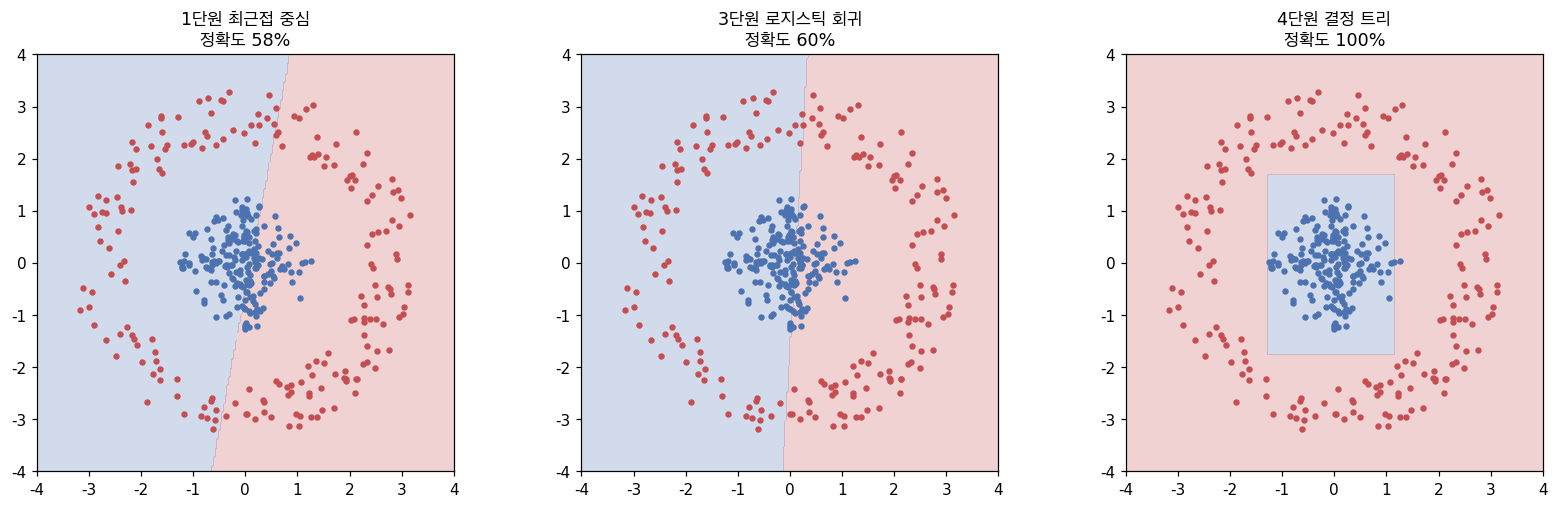

오른쪽 트리의 경계를 보세요. '계단' 모양입니다.
트리는 항상 축에 수직인 선만 그을 수 있어서, 대각선이나 원은 계단으로 흉내 냅니다.
계단을 잘게 쪼개면 어떤 모양이든 만들 수 있습니다. 그게 트리의 힘입니다.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
gx, gy = np.meshgrid(np.linspace(-4, 4, 250), np.linspace(-4, 4, 250))
격자 = np.c_[gx.ravel(), gy.ravel()]

예측들 = [
    ("1단원 최근접 중심",
     (np.linalg.norm(격자-중심1, axis=1) < np.linalg.norm(격자-중심0, axis=1)).astype(int)),
    ("3단원 로지스틱 회귀", (시그모이드(격자@w+b) >= 0.5).astype(int)),
    ("4단원 결정 트리", 도넛트리.예측(격자)),
]
for ax, (이름, 격자예측) in zip(axes, 예측들):
    ax.contourf(gx, gy, 격자예측.reshape(gx.shape), levels=[-0.5, 0.5, 1.5],
                colors=["#4c72b0", "#c44e52"], alpha=0.25)
    ax.scatter(X도넛[y도넛==0,0], X도넛[y도넛==0,1], s=10, color="#4c72b0")
    ax.scatter(X도넛[y도넛==1,0], X도넛[y도넛==1,1], s=10, color="#c44e52")
    if "중심" in 이름:
        정확도 = np.mean(중심예측==y도넛)
    elif "로지" in 이름:
        정확도 = np.mean(로지예측==y도넛)
    else:
        정확도 = np.mean(도넛트리.예측(X도넛)==y도넛)
    ax.set_title(f"{이름}\n정확도 {정확도:.0%}", fontsize=11.5)
    ax.set_aspect("equal"); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()

print("오른쪽 트리의 경계를 보세요. '계단' 모양입니다.")
print("트리는 항상 축에 수직인 선만 그을 수 있어서, 대각선이나 원은 계단으로 흉내 냅니다.")
print("계단을 잘게 쪼개면 어떤 모양이든 만들 수 있습니다. 그게 트리의 힘입니다.")

## 5️⃣ 멈추는 조건 — 안 그러면 다 외웁니다

> 🔗 **앞 절과 이어서** — 4절의 재귀는 **언제 멈추죠?**
> 안 멈추면 잎마다 점이 하나씩 남을 때까지 자릅니다. 그러면 훈련 정확도 100%예요.
> **1단원에서 본 과적합이 트리에서는 이렇게 나타납니다.**

> 📗 **원문** — "Stopping conditions"

원문 표현:

> **"멈추는 조건이 없으면 트리는 모든 잎이 순수해질 때까지(잎마다 샘플 하나씩) 자랍니다.
> 이건 훈련 데이터를 완벽히 외우는 것이고, 일반화는 최악이 됩니다."**

1단원 6절의 **과적합**이 트리에서는 이렇게 나타납니다.

### 📐 미리 막기 (Pre-pruning)

트리가 다 자라기 전에 멈춥니다.

| 조건 | 뜻 |
| --- | --- |
| **최대 깊이** | "질문을 5번 이상은 하지 마" |
| **최소 샘플 수** | "10명보다 적으면 더 안 나눠" |
| **최소 정보 이득** | "별로 안 깔끔해지면 그만둬" |

### 📐 나중에 자르기 (Post-pruning)

일단 크게 키운 다음, **도움 안 되는 가지를 잘라냅니다.**
더 좋은 결과를 내지만 계산이 오래 걸려요.

> ✨ **추가 실험** — 깊이를 바꿔 가며 과적합이 일어나는 걸 직접 봅시다.

In [9]:
# 잡음이 조금 섞인 데이터를 만듭니다
rng2 = np.random.default_rng(3)
n = 300
X실험 = rng2.normal(size=(n, 2))
y실험 = ((X실험[:, 0] + X실험[:, 1]) > 0).astype(int)
뒤집기 = rng2.random(n) < 0.1          # 10%는 일부러 라벨을 뒤집습니다 (잡음)
y실험 = np.where(뒤집기, 1 - y실험, y실험)

X훈련, y훈련 = X실험[:200], y실험[:200]
X테스트, y테스트 = X실험[200:], y실험[200:]

print("깊이를 늘려 가며 훈련/테스트 정확도를 봅니다")
print("(데이터에 10%의 잡음이 섞여 있습니다)\n")
print(f"{'최대 깊이':>10}{'잎 개수':>10}{'훈련 정확도':>14}{'테스트 정확도':>16}{'상태':>14}")
print("-" * 66)

def 잎개수(노드_):
    if 노드_.잎인가():
        return 1
    return 잎개수(노드_.왼쪽) + 잎개수(노드_.오른쪽)

결과들 = []
for 깊이 in [1, 2, 3, 5, 8, 15]:
    t = 결정트리(최대깊이=깊이, 최소샘플=1).학습(X훈련, y훈련)
    훈련점수 = np.mean(t.예측(X훈련) == y훈련)
    테스트점수 = np.mean(t.예측(X테스트) == y테스트)
    결과들.append((깊이, 훈련점수, 테스트점수))
    print(f"{깊이:>10}{잎개수(t.뿌리):>10}{훈련점수:>14.1%}{테스트점수:>16.1%}", end="")
    print(f"{'':>14}")

최적깊이 = max(결과들, key=lambda r: r[2])[0]
print(f"\n=> 테스트 정확도가 가장 높은 깊이는 {최적깊이}입니다.")
print("   깊이를 더 늘리면 훈련 정확도는 계속 올라가지만(외우니까),")
print("   테스트 정확도는 오히려 떨어집니다. 잡음까지 외웠기 때문이에요.")
print("\n💡 '깊이'는 사람이 정해 주는 값(하이퍼파라미터)입니다.")
print("   너무 얕으면 못 배우고, 너무 깊으면 외웁니다.")

깊이를 늘려 가며 훈련/테스트 정확도를 봅니다
(데이터에 10%의 잡음이 섞여 있습니다)

     최대 깊이      잎 개수        훈련 정확도         테스트 정확도            상태
------------------------------------------------------------------
         1         2         77.0%           70.0%              
         2         4         82.5%           74.0%              
         3         8         85.0%           73.0%              
         5        18         91.5%           78.0%              
         8        29         95.5%           76.0%              
        15        42         99.5%           77.0%              

=> 테스트 정확도가 가장 높은 깊이는 5입니다.
   깊이를 더 늘리면 훈련 정확도는 계속 올라가지만(외우니까),
   테스트 정확도는 오히려 떨어집니다. 잡음까지 외웠기 때문이에요.

💡 '깊이'는 사람이 정해 주는 값(하이퍼파라미터)입니다.
   너무 얕으면 못 배우고, 너무 깊으면 외웁니다.


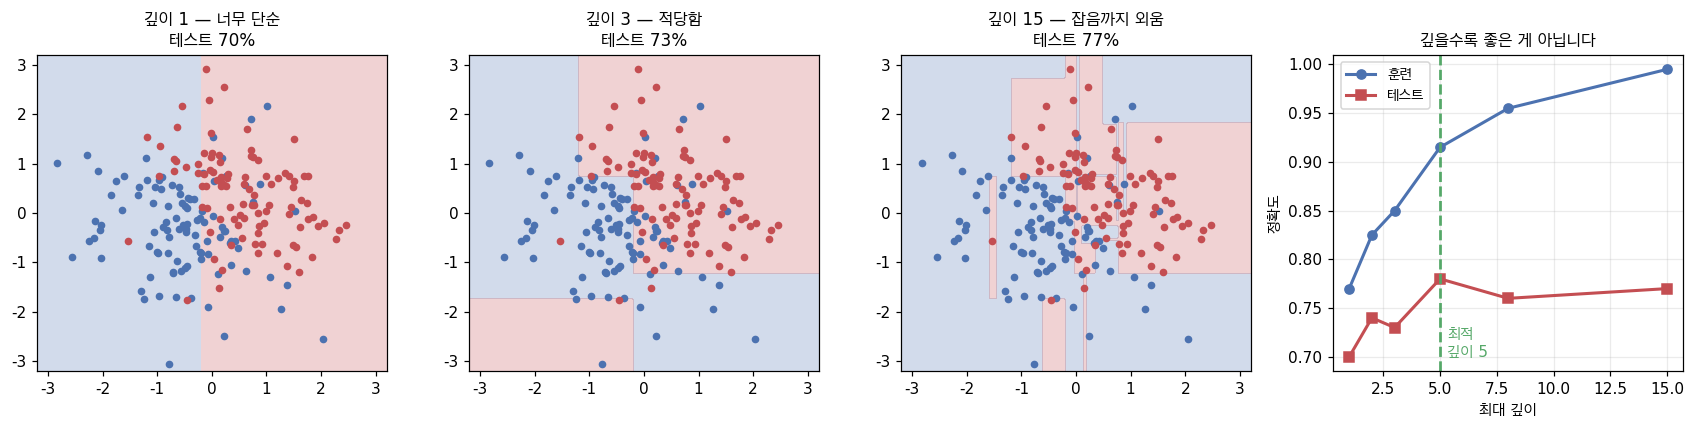

오른쪽 그림: 파란 선(훈련)은 계속 올라가는데 빨간 선(테스트)은 내려옵니다.
두 선이 벌어지는 순간이 '외우기 시작한' 시점입니다.

세 번째 그림의 경계를 보세요. 잡음 점 하나하나를 감싸려고 삐죽삐죽합니다.


In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4))
gx2, gy2 = np.meshgrid(np.linspace(-3.2, 3.2, 200), np.linspace(-3.2, 3.2, 200))
격자2 = np.c_[gx2.ravel(), gy2.ravel()]

for ax, 깊이 in zip(axes[:3], [1, 3, 15]):
    t = 결정트리(최대깊이=깊이, 최소샘플=1).학습(X훈련, y훈련)
    ax.contourf(gx2, gy2, t.예측(격자2).reshape(gx2.shape), levels=[-0.5, 0.5, 1.5],
                colors=["#4c72b0", "#c44e52"], alpha=0.25)
    ax.scatter(X훈련[y훈련==0,0], X훈련[y훈련==0,1], s=16, color="#4c72b0")
    ax.scatter(X훈련[y훈련==1,0], X훈련[y훈련==1,1], s=16, color="#c44e52")
    설명 = {1: "깊이 1 — 너무 단순", 3: "깊이 3 — 적당함",
            15: "깊이 15 — 잡음까지 외움"}[깊이]
    ax.set_title(f"{설명}\n테스트 {np.mean(t.예측(X테스트)==y테스트):.0%}", fontsize=11)
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)

깊이들 = [r[0] for r in 결과들]
axes[3].plot(깊이들, [r[1] for r in 결과들], "o-", lw=2, color="#4c72b0", label="훈련")
axes[3].plot(깊이들, [r[2] for r in 결과들], "s-", lw=2, color="#c44e52", label="테스트")
axes[3].axvline(최적깊이, color="#55a868", ls="--", lw=1.8)
axes[3].text(최적깊이+0.3, 0.7, f"최적\n깊이 {최적깊이}", fontsize=10, color="#55a868")
axes[3].set_xlabel("최대 깊이"); axes[3].set_ylabel("정확도")
axes[3].set_title("깊을수록 좋은 게 아닙니다", fontsize=11)
axes[3].legend(fontsize=9.5); axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("오른쪽 그림: 파란 선(훈련)은 계속 올라가는데 빨간 선(테스트)은 내려옵니다.")
print("두 선이 벌어지는 순간이 '외우기 시작한' 시점입니다.")
print("\n세 번째 그림의 경계를 보세요. 잡음 점 하나하나를 감싸려고 삐죽삐죽합니다.")

## 6️⃣ 숫자를 예측하는 트리

> 🔗 **앞 절과 이어서** — 여기까지 전부 **분류**였습니다. 숫자 예측은요?
> 놀랍게도 **1절의 불순도만 바꾸면** 됩니다. 지니 대신 **분산**을 쓰는 거죠.
> 나머지 코드(2·3·4절)는 그대로입니다.

> 📗 **원문** — "Decision trees for regression"

트리로 **숫자도 예측**할 수 있습니다. 두 군데만 바꾸면 됩니다.

| | 분류 트리 | 회귀 트리 |
| --- | --- | --- |
| 불순도 재는 법 | 지니 / 엔트로피 | **분산 (또는 MSE)** |
| 잎에서 하는 답 | 가장 많은 종류 | **평균값** |

### 🧸 말로 풀면

- **분류**: "이 그룹에 고양이가 많나 강아지가 많나?" → 많은 쪽으로 답
- **회귀**: "이 그룹의 값들이 얼마나 흩어져 있나?" → 평균으로 답

### ⚠️ 회귀 트리의 특징

**답이 '계단 모양'으로 나옵니다.** 잎마다 하나의 값(평균)만 내놓으니까요.
부드러운 곡선은 만들 수 없습니다.

In [11]:
def 분산불순도(값들):
    return float(np.var(값들)) if len(값들) > 0 else 0.0

class 회귀트리:
    def __init__(self, 최대깊이=4, 최소샘플=5):
        self.최대깊이 = 최대깊이
        self.최소샘플 = 최소샘플

    def 학습(self, X, y):
        self.뿌리 = self._키우기(X, y, 0)
        return self

    def _키우기(self, X, y, 깊이):
        if 깊이 >= self.최대깊이 or len(y) < self.최소샘플:
            return 노드(예측값=float(np.mean(y)))      # 잎에서는 '평균'을 답합니다
        최고이득, 최적특징, 최적기준 = -1.0, None, None
        for f in range(X.shape[1]):
            값들 = np.unique(X[:, f])
            for 기준 in (값들[:-1] + 값들[1:]) / 2:
                왼, 오 = y[X[:, f] <= 기준], y[X[:, f] > 기준]
                if len(왼) == 0 or len(오) == 0:
                    continue
                자른후 = (len(왼)*분산불순도(왼) + len(오)*분산불순도(오)) / len(y)
                이득 = 분산불순도(y) - 자른후
                if 이득 > 최고이득:
                    최고이득, 최적특징, 최적기준 = 이득, f, 기준
        if 최적특징 is None or 최고이득 <= 1e-12:
            return 노드(예측값=float(np.mean(y)))
        마스크 = X[:, 최적특징] <= 최적기준
        return 노드(특징=최적특징, 기준=최적기준,
                    왼쪽=self._키우기(X[마스크], y[마스크], 깊이+1),
                    오른쪽=self._키우기(X[~마스크], y[~마스크], 깊이+1))

    def _한개(self, x, n):
        if n.잎인가():
            return n.예측값
        return self._한개(x, n.왼쪽 if x[n.특징] <= n.기준 else n.오른쪽)

    def 예측(self, X):
        return np.array([self._한개(x, self.뿌리) for x in X])

# 곡선 데이터
rng3 = np.random.default_rng(0)
X회귀 = np.sort(rng3.uniform(-3, 3, 80)).reshape(-1, 1)
y회귀 = np.sin(X회귀.ravel()) * 2 + rng3.normal(0, 0.3, 80)

print("사인 곡선을 트리로 맞춰 봅니다\n")
print(f"{'최대 깊이':>10}{'MSE':>12}{'답의 종류 수':>16}")
print("-" * 40)
for 깊이 in [1, 2, 4, 8]:
    rt = 회귀트리(최대깊이=깊이).학습(X회귀, y회귀)
    예측 = rt.예측(X회귀)
    print(f"{깊이:>10}{np.mean((예측-y회귀)**2):>12.4f}{len(np.unique(예측)):>16}")

print("\n=> 깊이가 깊어질수록 '답의 종류'가 늘어납니다.")
print("   깊이 1이면 답이 2가지뿐입니다 (잎이 2개니까요).")
print("   그래서 계단이 성기고, 곡선을 잘 못 따라갑니다.")

사인 곡선을 트리로 맞춰 봅니다

     최대 깊이         MSE         답의 종류 수
----------------------------------------
         1      0.3652               2
         2      0.2625               4
         4      0.0613              13
         8      0.0210              30

=> 깊이가 깊어질수록 '답의 종류'가 늘어납니다.
   깊이 1이면 답이 2가지뿐입니다 (잎이 2개니까요).
   그래서 계단이 성기고, 곡선을 잘 못 따라갑니다.


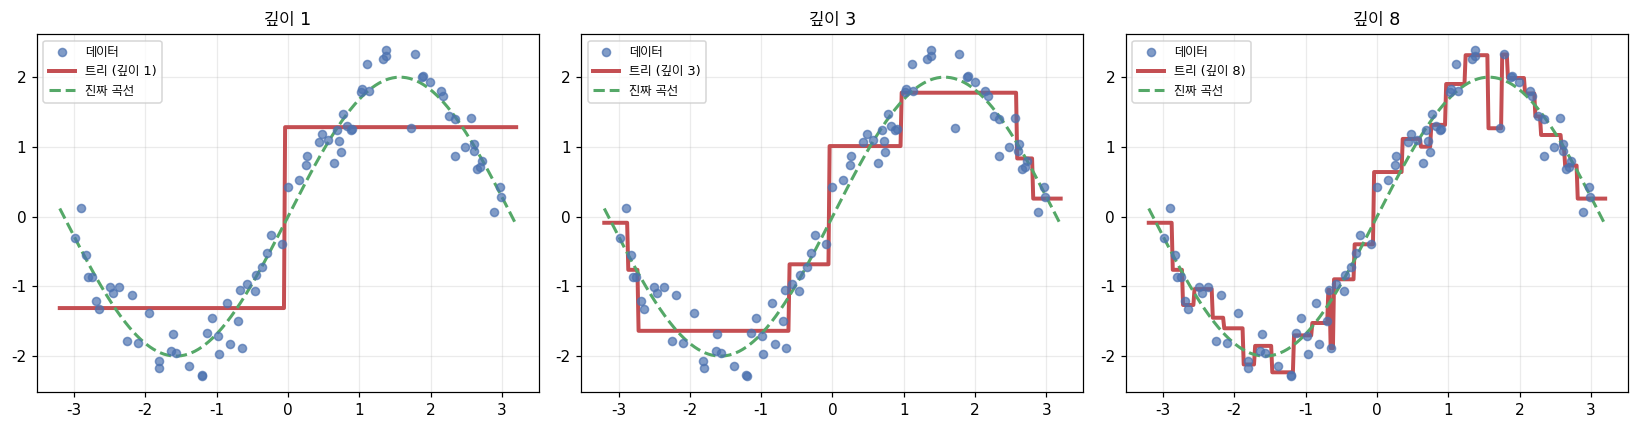

빨간 선이 '계단' 모양인 걸 보세요. 이게 회귀 트리의 특징입니다.
잎마다 하나의 값(평균)만 답하니까 부드러운 곡선이 안 나옵니다.
계단을 잘게 만들면 곡선에 가까워지지만, 그러면 과적합 위험이 커집니다.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
xs = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)
for ax, 깊이 in zip(axes, [1, 3, 8]):
    rt = 회귀트리(최대깊이=깊이).학습(X회귀, y회귀)
    ax.scatter(X회귀, y회귀, s=28, color="#4c72b0", alpha=0.7, zorder=5, label="데이터")
    ax.plot(xs, rt.예측(xs), lw=2.6, color="#c44e52", label=f"트리 (깊이 {깊이})")
    ax.plot(xs, np.sin(xs.ravel())*2, lw=2, color="#55a868", ls="--", label="진짜 곡선")
    ax.set_title(f"깊이 {깊이}", fontsize=11.5)
    ax.legend(fontsize=8.5); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("빨간 선이 '계단' 모양인 걸 보세요. 이게 회귀 트리의 특징입니다.")
print("잎마다 하나의 값(평균)만 답하니까 부드러운 곡선이 안 나옵니다.")
print("계단을 잘게 만들면 곡선에 가까워지지만, 그러면 과적합 위험이 커집니다.")

## 7️⃣ 🔑 랜덤 포레스트 — 나무 여러 그루 심기

> 🔗 **여기서 트리의 근본 약점을 만납니다** — 5절에서 깊이를 제한해 과적합은 눌렀습니다.
> 그런데 더 깊은 문제가 남아 있습니다. **나무 한 그루는 불안정합니다.**
> 훈련 데이터가 조금만 바뀌어도 위쪽 질문이 통째로 달라지고, 그 아래가 전부 달라지거든요.
> **여러 그루를 심어 다수결**을 하면 이게 잡힙니다.

> 📗 **원문** — "Random forests: the power of ensembles"

### ⚠️ 나무 한 그루의 문제

원문 표현:

> **"결정 트리 하나는 분산이 큽니다. 데이터가 조금만 바뀌어도 완전히 다른 트리가 나옵니다."**

**같은 문제를 두 번 풀었는데 답이 다르게 나오는** 셈이에요. 불안정합니다.

### 🧸 해결책 — 여러 사람에게 물어보기

한 사람에게 물으면 그 사람 취향이 섞입니다.
**100명에게 묻고 다수결**을 하면 개인의 편향이 상쇄됩니다.

**랜덤 포레스트가 정확히 이겁니다.** 나무를 여러 그루 심고 투표하게 해요.

### 📐 나무들을 '서로 다르게' 만드는 두 가지 장치

**① 배깅(bagging) — 데이터를 다르게 줍니다**

각 나무에게 **원본에서 중복 허용으로 뽑은 샘플**을 줍니다.
그러면 나무마다 조금씩 다른 데이터를 보게 되죠.

> 📗 원문: "약 63%의 원본 샘플이 각 부트스트랩에 나타납니다"
> (나머지는 **OOB 샘플**이라 부르고, 검증에 쓸 수 있습니다)

**② 특징 무작위화 — 볼 수 있는 특징을 제한합니다**

각 질문마다 **특징 일부만** 보게 합니다.
안 그러면 모든 나무가 똑같이 "제일 좋은 특징"만 쓰게 되거든요.

> 분류에서는 보통 `√(특징 수)`개, 회귀에서는 `특징 수 / 3`개

### 🔑 핵심 원리

> 📗 **원문** — "서로 다른 나무를 평균 내면 **편향은 그대로 두고 분산만 줄어듭니다.**
> 나무 하나하나는 평범할 수 있지만, 앙상블은 강합니다."

> ✨ **추가** — 왜 63%인지 직접 확인해 봅시다. 원문에는 숫자만 나옵니다.

In [13]:
# ✨ 추가 — 부트스트랩에서 왜 63%가 나오는지
print("n개 중에 n번 뽑을 때(중복 허용), 특정 하나가 '한 번도 안 뽑힐' 확률\n")
print(f"{'데이터 개수 n':>14}{'안 뽑힐 확률':>16}{'뽑힐 확률':>14}")
print("-" * 46)
for n_ in [5, 10, 100, 1000, 10000]:
    안뽑힐확률 = (1 - 1/n_) ** n_
    print(f"{n_:>14}{안뽑힐확률:>16.4f}{1-안뽑힐확률:>14.4f}")
print(f"\n  n이 커지면 1/e = {1/math.e:.4f} 로 수렴합니다.")
print(f"  따라서 뽑힐 확률은 1 - 1/e = {1-1/math.e:.4f}, 즉 약 63%입니다.")

# 실제로 뽑아서 확인
rng4 = np.random.default_rng(0)
n_ = 1000
포함비율 = []
for _ in range(200):
    뽑힌것 = rng4.integers(0, n_, n_)
    포함비율.append(len(set(뽑힌것)) / n_)
print(f"\n  실제로 200번 뽑아 본 결과: 평균 {np.mean(포함비율):.4f}  ✓")

n개 중에 n번 뽑을 때(중복 허용), 특정 하나가 '한 번도 안 뽑힐' 확률

      데이터 개수 n         안 뽑힐 확률         뽑힐 확률
----------------------------------------------
             5          0.3277        0.6723
            10          0.3487        0.6513
           100          0.3660        0.6340
          1000          0.3677        0.6323
         10000          0.3679        0.6321

  n이 커지면 1/e = 0.3679 로 수렴합니다.
  따라서 뽑힐 확률은 1 - 1/e = 0.6321, 즉 약 63%입니다.

  실제로 200번 뽑아 본 결과: 평균 0.6330  ✓


In [14]:
class 랜덤포레스트:
    def __init__(self, 나무수=20, 최대깊이=6, 특징수=None, 시드=0):
        self.나무수 = 나무수
        self.최대깊이 = 최대깊이
        self.특징수 = 특징수      # None이면 √(전체 특징 수)
        self.시드 = 시드

    def 학습(self, X, y):
        rng_ = np.random.default_rng(self.시드)
        n, d = X.shape
        self.특징수_ = self.특징수 or max(1, int(round(math.sqrt(d))))
        self.나무들 = []
        for i in range(self.나무수):
            # ① 배깅: 중복을 허용해 n개를 다시 뽑습니다 (나무마다 다른 데이터)
            뽑기 = rng_.integers(0, n, n)
            # ② 특징 무작위화: 나무 안에서 '분할할 때마다' 특징 일부를 새로 뽑습니다
            #    (나무마다 한 번만 고정하면 정답 특징을 아예 못 보는 나무가 생깁니다)
            t = 결정트리(최대깊이=self.최대깊이, 최소샘플=2,
                         분할당특징수=self.특징수_, 시드=int(rng_.integers(0, 10**6)))
            t.학습(X[뽑기], y[뽑기])
            self.나무들.append(t)
        return self

    def 예측(self, X):
        # 모든 나무의 답을 모아 다수결
        표 = np.array([t.예측(X) for t in self.나무들])
        return np.array([Counter(표[:, i]).most_common(1)[0][0] for i in range(len(X))])


# 잡음이 섞인 5차원 데이터를 만듭니다
def 숲데이터만들기(시드, n=1000, 잡음=0.10, 특징개수=10):
    # 특징 10개 중 앞의 2개만 정답에 쓰이고, 나머지 8개는 아무 상관 없는 잡음입니다.
    # (특징이 5개뿐이면 √5=2개만 보는 나무가 정답 특징을 못 볼 수 있어서 10개로 잡았습니다)
    r = np.random.default_rng(시드)
    X = r.normal(size=(n, 특징개수))
    y = ((X[:, 0] + X[:, 1]) > 0).astype(int)      # 특징 0, 1만 사용
    y = np.where(r.random(n) < 잡음, 1 - y, y)      # 10%는 라벨을 뒤집음 (잡음)
    k = int(n * 0.7)
    return X[:k], y[:k], X[k:], y[k:]

X숲훈련, y숲훈련, X숲테스트, y숲테스트 = 숲데이터만들기(5)

# ⚠️ 한 번만 돌리면 운에 좌우됩니다. 시드 10개로 평균을 냅니다.
print("나무 한 그루 vs 여러 그루 (특징 10개 중 2개만 유효, 잡음 10%)")
print("데이터를 10번 새로 만들어 평균 낸 결과입니다.\n")
print(f"{'모델':<24}{'훈련 정확도':>14}{'테스트 정확도':>16}")
print("-" * 56)

def 평균성능(만들기, 시드들=range(10)):
    훈련들, 테스트들 = [], []
    for sd in 시드들:
        Xtr, ytr, Xte, yte = 숲데이터만들기(sd)
        m = 만들기(sd).학습(Xtr, ytr)
        훈련들.append(np.mean(m.예측(Xtr) == ytr))
        테스트들.append(np.mean(m.예측(Xte) == yte))
    return np.mean(훈련들), np.mean(테스트들)

트리훈련, 트리테스트 = 평균성능(lambda sd: 결정트리(최대깊이=8))
print(f"{'결정 트리 1그루':<23}{트리훈련:>14.1%}{트리테스트:>16.1%}")
숲결과표 = []
for 나무수 in [5, 20, 50]:
    a, b = 평균성능(lambda sd, k=나무수: 랜덤포레스트(나무수=k, 최대깊이=8, 시드=sd))
    숲결과표.append((나무수, a, b))
    print(f"{f'랜덤 포레스트 {나무수}그루':<22}{a:>14.1%}{b:>16.1%}")

print(f"\n=> 나무를 늘릴수록 테스트 정확도가 올라갑니다.")
print(f"   1그루 {트리테스트:.1%} -> 50그루 {숲결과표[-1][2]:.1%} "
      f"({숲결과표[-1][2]-트리테스트:+.1%}p)")
print("\n💡 이게 앙상블의 마법입니다. 나무들이 각자 '다른 실수'를 하니까")
print("   다수결을 하면 실수가 서로 상쇄됩니다.")

나무 한 그루 vs 여러 그루 (특징 10개 중 2개만 유효, 잡음 10%)
데이터를 10번 새로 만들어 평균 낸 결과입니다.

모델                              훈련 정확도         테스트 정확도
--------------------------------------------------------
결정 트리 1그루                       96.3%           79.5%
랜덤 포레스트 5그루                    93.9%           80.2%
랜덤 포레스트 20그루                   95.2%           83.5%
랜덤 포레스트 50그루                   95.7%           85.0%

=> 나무를 늘릴수록 테스트 정확도가 올라갑니다.
   1그루 79.5% -> 50그루 85.0% (+5.5%p)

💡 이게 앙상블의 마법입니다. 나무들이 각자 '다른 실수'를 하니까
   다수결을 하면 실수가 서로 상쇄됩니다.


> ✨ **추가** — '나무 한 그루는 불안정하다'를 직접 확인합니다.

In [15]:
# ✨ 추가 — '트리 한 그루는 불안정하다'를 확인합니다
# 같은 문제인데 훈련 데이터를 조금씩 바꿔 가며 12번 학습시켜 봅니다
print("훈련 데이터의 80%씩만 뽑아 12번 학습시켜 봅니다")
print("(테스트 데이터는 고정입니다. 훈련 데이터만 흔들었어요)\n")

트리결과들, 숲결과들 = [], []
for 시드 in range(12):
    r = np.random.default_rng(100 + 시드)
    뽑기 = r.choice(len(X숲훈련), int(len(X숲훈련) * 0.8), replace=False)
    t = 결정트리(최대깊이=8).학습(X숲훈련[뽑기], y숲훈련[뽑기])
    트리결과들.append(np.mean(t.예측(X숲테스트) == y숲테스트))
    # 숲의 시드는 고정합니다. 그래야 '데이터만 흔들었을 때'를 비교할 수 있어요
    f = 랜덤포레스트(나무수=25, 최대깊이=8, 시드=0).학습(X숲훈련[뽑기], y숲훈련[뽑기])
    숲결과들.append(np.mean(f.예측(X숲테스트) == y숲테스트))

print(f"{'':<18}{'평균':>10}{'최저':>10}{'최고':>10}{'흔들린 폭':>12}{'표준편차':>12}")
print("-" * 74)
print(f"{'트리 1그루':<17}{np.mean(트리결과들):>10.1%}{min(트리결과들):>10.1%}"
      f"{max(트리결과들):>10.1%}{max(트리결과들)-min(트리결과들):>11.1%}p"
      f"{np.std(트리결과들):>12.4f}")
print(f"{'랜덤 포레스트':<16}{np.mean(숲결과들):>10.1%}{min(숲결과들):>10.1%}"
      f"{max(숲결과들):>10.1%}{max(숲결과들)-min(숲결과들):>11.1%}p"
      f"{np.std(숲결과들):>12.4f}")

print(f"\n=> 두 가지를 보세요.")
print(f"   ① 평균이 더 높습니다: {np.mean(트리결과들):.1%} -> {np.mean(숲결과들):.1%}")
print(f"   ② 덜 흔들립니다: 표준편차 {np.std(트리결과들):.4f} -> {np.std(숲결과들):.4f}")
print("\n   ②번이 '분산을 줄인다'는 말의 정확한 의미입니다.")
print("   같은 문제를 다시 풀어도 비슷한 답이 나온다는 뜻이죠.")

훈련 데이터의 80%씩만 뽑아 12번 학습시켜 봅니다
(테스트 데이터는 고정입니다. 훈련 데이터만 흔들었어요)

                          평균        최저        최고       흔들린 폭        표준편차
--------------------------------------------------------------------------
트리 1그루                79.0%     77.0%     82.0%       5.0%p      0.0137
랜덤 포레스트              83.4%     82.0%     86.0%       4.0%p      0.0128

=> 두 가지를 보세요.
   ① 평균이 더 높습니다: 79.0% -> 83.4%
   ② 덜 흔들립니다: 표준편차 0.0137 -> 0.0128

   ②번이 '분산을 줄인다'는 말의 정확한 의미입니다.
   같은 문제를 다시 풀어도 비슷한 답이 나온다는 뜻이죠.


## 8️⃣ 특징 중요도

> 🔗 **앞 절과 이어서** — 7절에서 성능은 올렸는데 **잃은 게 하나 있습니다.**
> 0절에서 자랑했던 "규칙을 읽을 수 있다"는 장점이요. 나무가 50그루면 못 읽습니다.
> 대신 **"어떤 특징이 중요했나"**는 뽑아낼 수 있습니다.

> 📗 **원문** — "Feature importance"

트리는 **"어떤 정보가 중요했는지"** 를 자동으로 알려 줍니다.

### 📐 방법 ① 불순도 감소량 (MDI)

각 특징이 **불순도를 얼마나 줄였는지** 전부 더합니다.

$$\text{중요도}(j) = \sum_{j\text{를 쓴 모든 노드}} \frac{\text{그 노드의 샘플 수}}{\text{전체 샘플 수}} \times \text{불순도 감소량}$$

**빠릅니다** (학습 중에 저절로 계산됨). 다만 **값의 종류가 많은 특징**을 과대평가하는 편향이 있습니다.

### 📐 방법 ② 순열 중요도 (Permutation importance)

한 특징의 값을 **마구 섞어 놓고** 정확도가 얼마나 떨어지는지 봅니다.

- 많이 떨어짐 → **중요한 특징**
- 안 떨어짐 → 없어도 되는 특징

**더 믿을 만하지만 느립니다.**

> 🧸 비유: 팀에서 한 명씩 빼 보면서 성과가 얼마나 나빠지는지 재는 것과 같습니다.

In [16]:
def 순열중요도(모델, X, y, 특징이름들, 반복=10, 시드=0):
    rng_ = np.random.default_rng(시드)
    기준점수 = np.mean(모델.예측(X) == y)
    결과 = []
    for f in range(X.shape[1]):
        떨어진정도 = []
        for _ in range(반복):
            X섞음 = X.copy()
            rng_.shuffle(X섞음[:, f])          # 이 특징만 마구 섞습니다
            떨어진정도.append(기준점수 - np.mean(모델.예측(X섞음) == y))
        결과.append(float(np.mean(떨어진정도)))
    return np.array(결과)

특징이름들 = [f"특징{i}" + (" (정답에 쓰임)" if i < 2 else " (무관)") for i in range(10)]

# 여러 번 재서 평균을 냅니다 (한 번만 재면 흔들립니다)
중요도모음 = []
for sd in range(8):
    Xtr, ytr, Xte, yte = 숲데이터만들기(sd)
    숲_ = 랜덤포레스트(나무수=30, 최대깊이=8, 시드=sd).학습(Xtr, ytr)
    중요도모음.append(순열중요도(숲_, Xte, yte, 특징이름들, 반복=5, 시드=sd))
중요도 = np.mean(중요도모음, axis=0)

print("정답 규칙: y = (특징0 + 특징1 > 0)")
print("           특징2~9 (8개)는 아무 관련이 없는 잡음입니다.")
print("           (데이터 8세트로 재서 평균 낸 값입니다)\n")
print(f"{'특징':<22}{'순열 중요도':>14}{'판정':>14}")
print("-" * 52)
for 이름, 값 in sorted(zip(특징이름들, 중요도), key=lambda t: -t[1]):
    판정 = "중요 ⭐" if 값 > 0.02 else "거의 무관"
    print(f"{이름:<22}{값:>14.4f}{판정:>14}")

print("\n=> 특징 0과 1만 확실히 위로 올라왔습니다.")
print("   나머지 8개는 전부 0 근처입니다.")
print("\n   우리가 알려준 적이 없는데 모델이 '어떤 특징이 쓸모 있는지' 스스로 알아냈습니다.")
print("\n💡 실무에서 아주 유용합니다.")
print("   '어떤 데이터를 더 모아야 하나?', '이 컬럼은 빼도 되나?'에 답을 줍니다.")
print("\n⚠️ 무관한 특징의 중요도가 살짝 '음수'로 나오기도 합니다.")
print("   섞었더니 우연히 정확도가 올라간 경우예요. 0으로 보시면 됩니다.")

정답 규칙: y = (특징0 + 특징1 > 0)
           특징2~9 (8개)는 아무 관련이 없는 잡음입니다.
           (데이터 8세트로 재서 평균 낸 값입니다)

특징                            순열 중요도            판정
----------------------------------------------------
특징1 (정답에 쓰임)                  0.2258          중요 ⭐
특징0 (정답에 쓰임)                  0.2018          중요 ⭐
특징2 (무관)                      0.0015         거의 무관
특징9 (무관)                      0.0007         거의 무관
특징8 (무관)                      0.0003         거의 무관
특징6 (무관)                      0.0003         거의 무관
특징3 (무관)                     -0.0001         거의 무관
특징5 (무관)                     -0.0006         거의 무관
특징4 (무관)                     -0.0025         거의 무관
특징7 (무관)                     -0.0049         거의 무관

=> 특징 0과 1만 확실히 위로 올라왔습니다.
   나머지 8개는 전부 0 근처입니다.

   우리가 알려준 적이 없는데 모델이 '어떤 특징이 쓸모 있는지' 스스로 알아냈습니다.

💡 실무에서 아주 유용합니다.
   '어떤 데이터를 더 모아야 하나?', '이 컬럼은 빼도 되나?'에 답을 줍니다.

⚠️ 무관한 특징의 중요도가 살짝 '음수'로 나오기도 합니다.
   섞었더니 우연히 정확도가 올라간 경우예요. 0으로 보시면 됩니다.


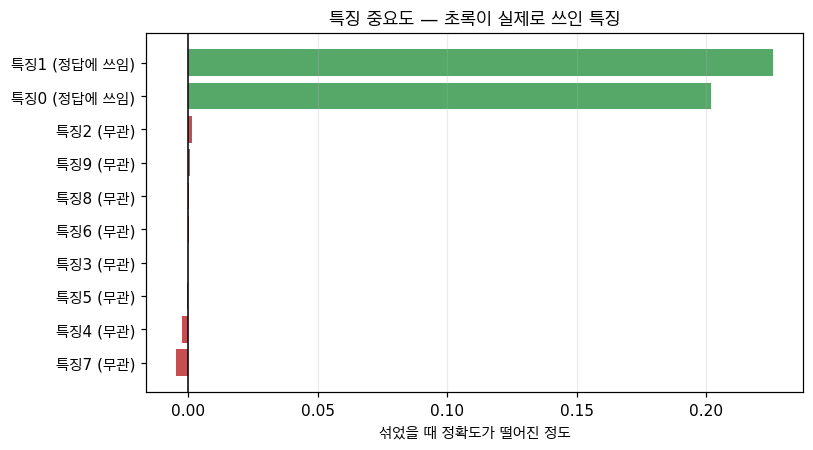

초록 막대 2개가 실제 정답 규칙에 쓰인 특징입니다.
나머지 8개(빨강)는 전부 0 근처예요 — 섞어도 아무 영향이 없다는 뜻입니다.

💡 실무에서는 이걸 보고 '쓸모없는 컬럼 8개를 빼자'고 판단할 수 있습니다.


In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
순서 = np.argsort(중요도)
색 = ["#55a868" if 중요도[i] > 0.02 else "#c44e52" for i in 순서]
ax.barh([특징이름들[i] for i in 순서], 중요도[순서], color=색)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("섞었을 때 정확도가 떨어진 정도")
ax.set_title("특징 중요도 — 초록이 실제로 쓰인 특징", fontsize=12)
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.show()

print("초록 막대 2개가 실제 정답 규칙에 쓰인 특징입니다.")
print("나머지 8개(빨강)는 전부 0 근처예요 — 섞어도 아무 영향이 없다는 뜻입니다.")
print("\n💡 실무에서는 이걸 보고 '쓸모없는 컬럼 8개를 빼자'고 판단할 수 있습니다.")

## 9️⃣ 트리가 신경망을 이기는 경우

> 🔗 **앞 절과 이어서** — 여기까지 트리 계열을 다 만들었습니다.
> 마지막으로 **실무에서 이게 어디에 놓이는지** 정리합니다.
> 요즘 다 딥러닝이라는데, 트리는 왜 아직도 쓰일까요?

> 📗 **원문** — "When trees beat neural networks"

**표 형태 데이터(tabular data)에서는 트리가 신경망을 이깁니다.** 이유가 여러 개예요.

| 항목 | 트리 | 신경망 |
| --- | --- | --- |
| 숫자+글자 섞인 데이터 | **그냥 됨** | 인코딩 필요 |
| 작은 데이터 (1만 행 미만) | **잘 됨** | 과적합함 |
| 특징 간 상호작용 | **분할로 자동 발견** | 구조 설계 필요 |
| 설명 가능성 | **완전 투명** | 블랙박스 |
| 학습 시간 | **몇 분** | 몇 시간 |
| 설정값 민감도 | **낮음** | 높음 |

### 🔑 정리하면

- **표 데이터** (엑셀 같은 데이터) → **트리 계열이 기본값**
- **이미지·소리·글** (공간이나 순서가 있는 데이터) → **신경망**

> 💡 캐글(Kaggle) 같은 대회에서 표 데이터 문제는
> 지금도 **XGBoost, LightGBM** 같은 트리 계열이 우승합니다.
> 딥러닝 시대에도 트리는 여전히 현역이에요.

## 🔟 용어 사전 · 연습문제

> 📗 **원문** — "Key Terms" · "Exercises"

### 용어 사전

| 용어 | 사람들이 하는 말 | 진짜 뜻 |
| --- | --- | --- |
| **결정 트리** | "스무고개" | 예/아니오 질문을 이어가며 공간을 사각형으로 쪼개는 모델 |
| **지니 불순도** | "얼마나 섞였나" | `1 - Σp²`. 무작위로 이름표를 붙였을 때 틀릴 확률 |
| **엔트로피** | "무질서한 정도" | `-Σp log₂p`. 결과를 알려면 질문을 몇 번 해야 하나 |
| **정보 이득** | "이 질문이 얼마나 도움 되나" | 자르기 전 불순도 − 자른 후 가중평균 불순도 |
| **탐욕적 분할** | "지금 최선만 고르기" | 각 단계에서 당장 가장 좋은 질문만 선택. 전체 최적은 보장 못 함 |
| **가지치기** | "쓸데없는 가지 자르기" | 과적합을 막으려고 트리를 작게 유지하는 것 |
| **배깅** | "데이터를 섞어 여러 번" | 중복 허용으로 뽑은 샘플로 여러 모델을 학습 |
| **OOB 샘플** | "안 뽑힌 데이터" | 부트스트랩에서 빠진 약 37%. 검증에 쓸 수 있음 |
| **랜덤 포레스트** | "나무 여러 그루" | 배깅 + 특징 무작위화로 만든 트리들의 다수결 |
| **특징 중요도** | "뭐가 중요했나" | 각 특징이 예측에 기여한 정도 |

---

### 연습문제

**1.** 고양이 8마리, 강아지 2마리인 그룹의 지니와 엔트로피를 **손으로** 계산해 보세요.
그리고 코드로 확인해 보세요.

**2.** 5절의 실험에서 `최소샘플`을 1이 아니라 20으로 바꿔 보세요.
깊이를 15로 해도 과적합이 덜 일어나나요? **왜 그럴까요?**

**3.** 7절의 랜덤 포레스트에서 `특징수`를 1로도 해 보고 5(전체)로도 해 보세요.
어느 쪽이 더 좋나요? **왜죠?**
(힌트: 특징을 전부 쓰면 나무들이 서로 비슷해집니다)

**4.** 4절의 도넛 데이터에서 트리 깊이를 2, 4, 10으로 바꿔 보세요.
경계 모양이 어떻게 달라지나요?

---

## 🎯 이 단원 한 문장 정리

> **결정 트리는 "가장 깔끔하게 갈라지는 질문"을 반복해서 찾는 것이고,
> 랜덤 포레스트는 그런 나무를 여러 그루 심어 다수결하는 것입니다.**

### 3단원까지와 비교

| | 1단원 | 2·3단원 | 4단원 |
| --- | --- | --- | --- |
| 방법 | 평균까지 거리 | 직선 + 경사하강법 | **질문 이어가기** |
| 경계 | 직선 | 직선 | **계단 (곡선 흉내 가능)** |
| 도넛 데이터 | ❌ 실패 | ❌ 실패 | **✅ 성공** |
| 설명 가능성 | 보통 | 보통 | **아주 좋음** |

### 꼭 기억할 것

1. **불순도가 낮아지는 질문**을 고르는 게 전부입니다
2. **멈추지 않으면 다 외웁니다.** 깊이 제한이 꼭 필요해요
3. **나무 하나는 불안정합니다.** 여러 그루를 심으면 안정됩니다
4. **표 데이터에서는 지금도 트리가 최강**입니다

### 다음 단원 예고

5단원 **서포트 벡터 머신(SVM)** 에서는
**"경계선을 그을 때 최대한 여유롭게 긋자"** 는 완전히 다른 아이디어를 봅니다.
그리고 **커널 트릭**으로 곡선 경계를 만드는 또 다른 방법을 배웁니다.

---

## 📖 더 읽을거리

> 📗 **원문** — "Further Reading"

- [scikit-learn 결정 트리 문서](https://scikit-learn.org/stable/modules/tree.html)
- [An Introduction to Statistical Learning](https://www.statlearning.com/) — 8장이 트리입니다 (무료)
- [XGBoost 문서](https://xgboost.readthedocs.io/) — 실무에서 가장 많이 쓰는 트리 계열 모델